<a href="https://colab.research.google.com/github/joisscamargo2805-coder/netflixdb/blob/main/Actividad2_RLM_matricula_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Actividad 2**

###**Maestría en Inteligencia Artificial Aplicada**
###**Curso: Inteligencia Artificial y Aprendizaje Automático**
####**Tecnológico de Monterrey**
#####**Prof Luis Eduardo Falcón Morales**

###**Nombre del estudiante: Leydy Johanna Camargo Medina

###**Matrícula: A01840540**


**NOTAS:**

*   Esta actividad la puedes realizar en Google-Colab.
*   Se trabajará solamente con el archivo "california_housing_train.csv".
*   Si no trabajas con Google-Colab, deberás descargar el archivo y trabajarlo en el editor de tu preferencia.
*   Esta actividad consta solamente de 3 ejercicios, dividios en 3 partes.
*   **Solamente debes modificar este archivo agregando tus líneas de código en las partes que se te indican.**
*   **Cualquier modificación fuera de estas áreas te restará puntos a la actividad.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import power_transform
from sklearn.preprocessing import FunctionTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

In [2]:
# Cargamos el archivo que está en la siguiente carpeta de Google-Colab:
DIR = "/content/sample_data/"
os.chdir(DIR)

misdatos = pd.read_csv("california_housing_train.csv", sep=",")
misdatos.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#**Ejercicio - 1: Matriz de Correlación de Pearson**

**PREGUNTAS:**

*   **Pregunta 1.1.** Investiga cuál es la importancia del coeficiente de correlación de Pearson y cómo puede utilizarse durante el análisis de los datos de un problema.

*   **Pregunta 1.2.** El coeficiente de correlación de Pearson, ¿para qué tipo de variables lo podemos aplicar?  

*   **Pregunta 1.3.** Despliega la matriz de correlación de las variables del dataframe "misdatos", incluyendo en cada celda de la matriz el valor numérico de la correlación entre cada par de variables. Al desplegar la matriz de correlación deberás además usar la opción del mapa de calor (heatmap) de la librería seaborn, usando el mapa de color 'BuGn'.

Puedes consultar la siguiente documentación:

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

https://seaborn.pydata.org/generated/seaborn.heatmap.html

https://matplotlib.org/stable/tutorials/colors/colormaps.html



### **Respuestas:**

* **Respuesta 1.1.**  

El coeficiente de correlación de Pearson es una medida estadística que permite identificar la relación lineal entre dos variables numéricas. Su valor se encuentra entre -1 y 1. Un valor cercano a 1 indica una correlación positiva fuerte, un valor cercano a -1 indica una correlación negativa fuerte y un valor cercano a 0 indica ausencia de relación lineal.

Durante el análisis de datos, este coeficiente es importante porque ayuda a identificar variables que tienen mayor relación con la variable objetivo. En problemas de regresión, permite detectar dependencias entre variables, reducir redundancia, identificar multicolinealidad y apoyar la selección de variables relevantes para mejorar el desempeño de los modelos de aprendizaje automático.


* **Respuesta 1.2.**  

La matriz de correlación permite visualizar de manera simultánea la relación existente entre todas las variables numéricas del conjunto de datos. El mapa de calor facilita interpretar visualmente cuáles variables tienen correlaciones positivas o negativas más fuertes.

En el problema de predicción de precios de viviendas en California, la matriz de correlación ayuda a identificar cuáles variables influyen más en el valor de la vivienda. Por ejemplo, variables como median_income suelen presentar una correlación positiva importante con median_house_value, mientras que otras variables pueden tener relaciones más débiles o negativas.


* **Respuesta 1.3.**  

A continuación, se genera la matriz de correlación de Pearson y el mapa de calor correspondiente para analizar las relaciones entre las variables del conjunto de datos.


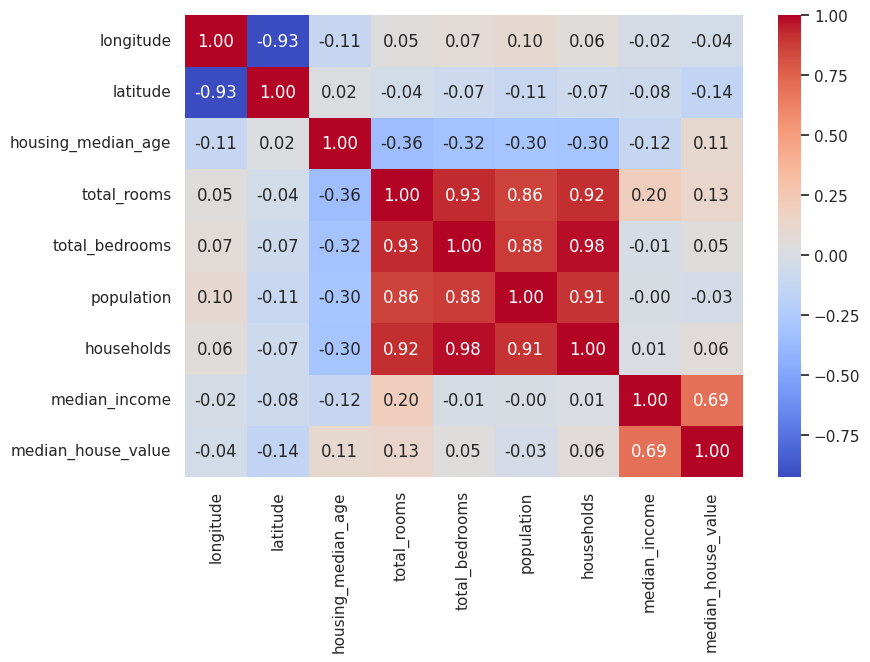

In [3]:

sns.set(rc={'figure.figsize':(9,6)})

#########################################################################
# INICIA LA SECCIÓN PARA AGREGAR CÓDIGO.
# Respuesta 1.3.

corr_matrix = misdatos.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

# TERMINA LA SECCIÓN PARA AGREGAR CÓDIGO.
#########################################################################

plt.show()


#**Ejercicio - 2: Transformaciones e Histogramas de variables**

**INSTRUCCIONES:**

En este ejercicio se trabajará solamente con las siguientes 7 variables:

*   housing_median_age
*   total_rooms
*   total_bedrooms
*   population
*   households
*   median_income
*   median_house_value

A cada una de dichas variables les deberás aplicar las siguientes transformaciones y desplegar sus histogramas con 20 barras (bins):

*   Raíz cuadrada con Numpy.
*   Logaritmo natural con Numpy.
*   Potencia 2 (i.e., elevar al cuadrado) con Numpy.
*   Investiga y aplica Box-Cox con scikit-learn.


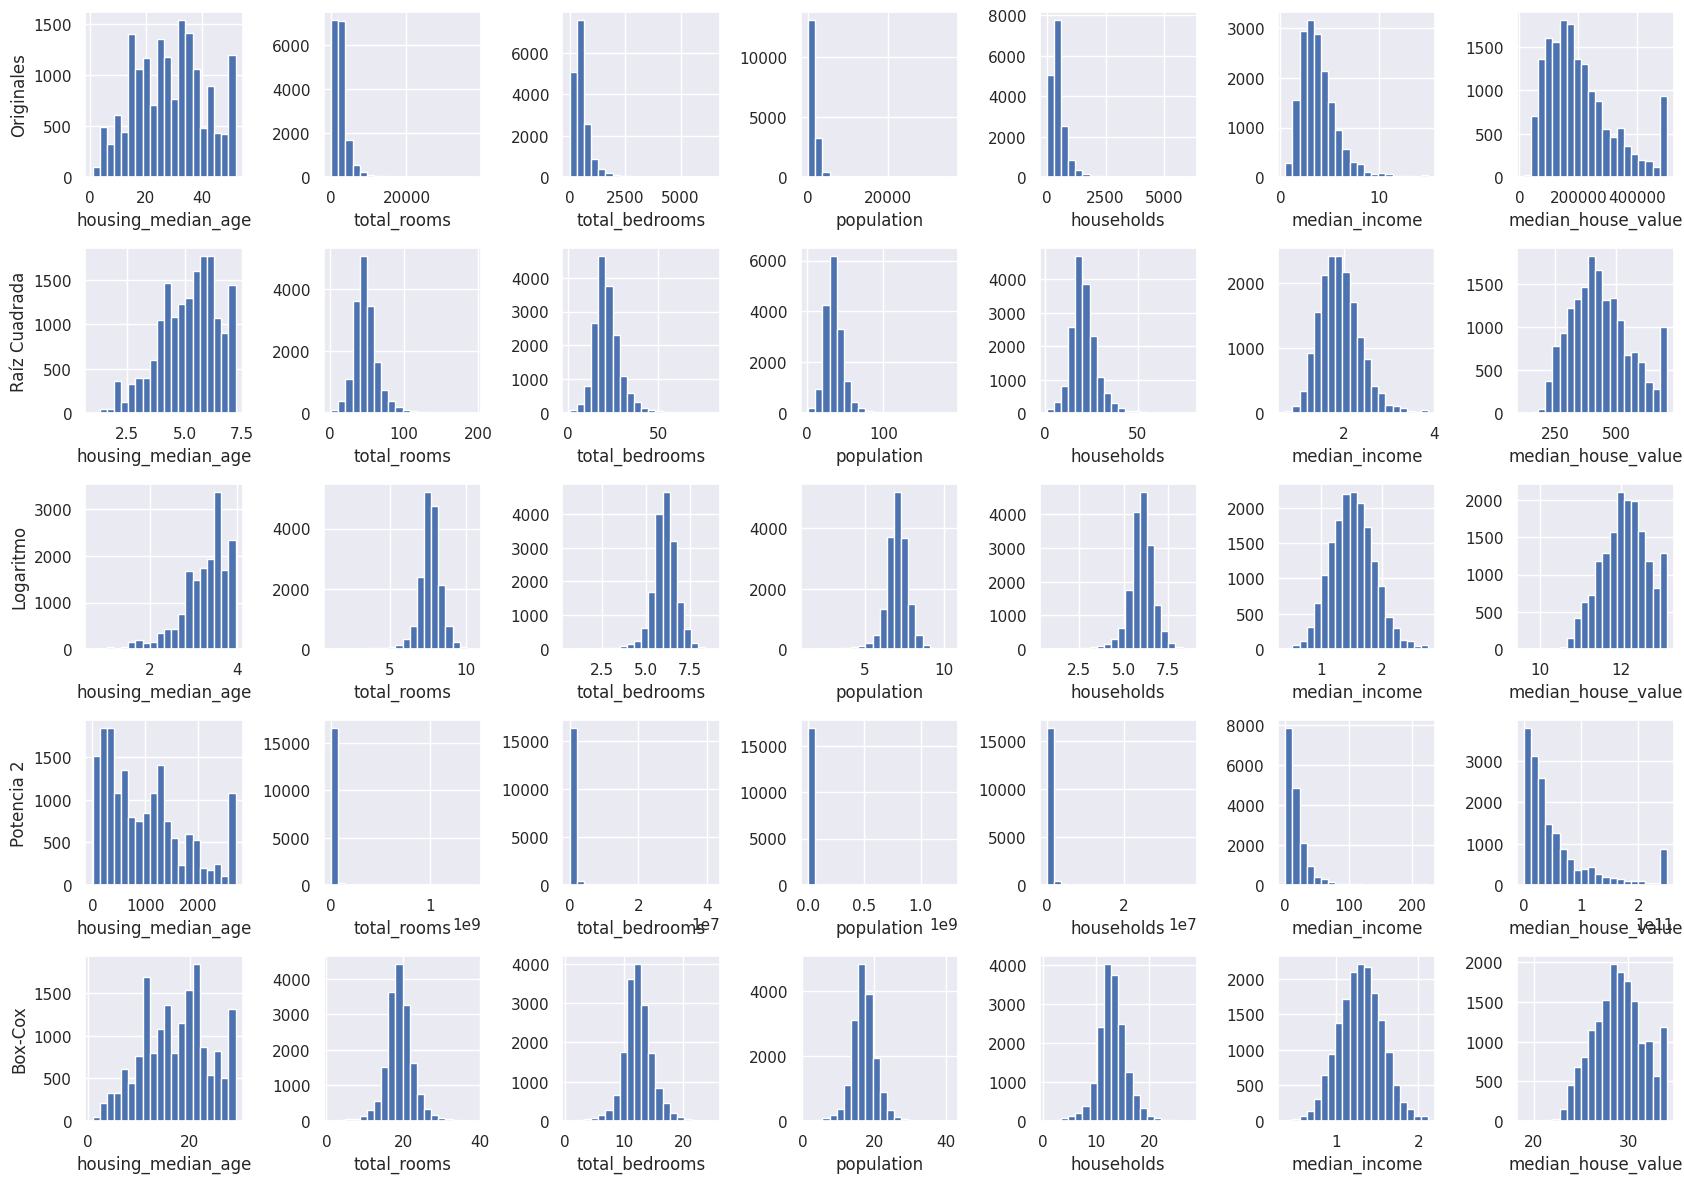

In [7]:
import scipy.stats as stats

# Lista de los nombres de las 7 variables que trabajaremos en este ejercicio.
variables_a_transformar = ['housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value']


sns.set(rc={'figure.figsize':(17,12)})
fig, axes = plt.subplots(5, 7)

for k in range(0,7):

    ################################################################################################################
    # INICIA LA SECCIÓN PARA AGREGAR CÓDIGO.

    datos = misdatos[variables_a_transformar[k]].values

    # Datos originales ---------------------------------------------------------
    plt.subplot(5,7,k+1)

    Transf0 = datos

    plt.hist(Transf0, bins=20)



    plt.xlabel(variables_a_transformar[k])
    if k==0:
      plt.ylabel('Originales')



    # Datos transformados con raíz cuadrada ------------------------------------
    plt.subplot(5,7,k+8)

    Transf1 = np.sqrt(datos)

    plt.hist(Transf1, bins=20)



    plt.xlabel(variables_a_transformar[k])
    if k==0:
      plt.ylabel('Raíz Cuadrada')



    # Datos transformados con logaritmo natural --------------------------------
    plt.subplot(5,7,k+15)

    Transf2 = np.log1p(datos)

    plt.hist(Transf2, bins=20)


    plt.xlabel(variables_a_transformar[k])
    if k==0:
      plt.ylabel('Logaritmo')



    # Datos transformados con la potencia de 2 ---------------------------------
    plt.subplot(5,7,k+22)

    Transf3 = np.power(datos, 2)

    plt.hist(Transf3, bins=20)



    plt.xlabel(variables_a_transformar[k])
    if k==0:
      plt.ylabel('Potencia 2')


    # Datos transformados con Box-Cox ------------------------------------------
    plt.subplot(5,7,k+29)

    datos_boxcox = datos + 1
    Transf4, _ = stats.boxcox(datos_boxcox)

    plt.hist(Transf4, bins=20)



    plt.xlabel(variables_a_transformar[k])
    if k==0:
      plt.ylabel('Box-Cox')

    # TERMINA LA SECCIÓN PARA AGREGAR CÓDIGO.
    ################################################################################################################


plt.tight_layout()
plt.show()

#**Ejercicio - 3 - Métricas de desempeño: $RMSE$, $MAE$ y $MAPE$**



#**Ejercicio - 3 - Métricas de desempeño: $RMSE$, $MAE$ y $MAPE$**

## Explicación de métricas

### RMSE (Root Mean Squared Error)
La métrica RMSE mide la raíz cuadrada del promedio de los errores al cuadrado entre los valores reales y las predicciones. Penaliza más los errores grandes y es ampliamente utilizada en problemas de regresión.

### MAE (Mean Absolute Error)
La métrica MAE mide el promedio absoluto de las diferencias entre los valores reales y predichos. Es una métrica fácil de interpretar y menos sensible a valores atípicos que RMSE.

### MAPE (Mean Absolute Percentage Error)
La métrica MAPE mide el porcentaje promedio del error absoluto respecto a los valores reales. Permite interpretar el error en términos porcentuales, facilitando el análisis del desempeño del modelo.


In [10]:

#########################################################################
# INICIA LA SECCIÓN PARA AGREGAR CÓDIGO.
# Ejercicio 3

# Incluye aquí las líneas de código que definan a la función mi_RMSE:

def mi_RMSE(yreal, ypred):
    return np.sqrt(np.mean((yreal - ypred)**2))




# Incluye aquí las líneas de código que definan a la función mi_MAE:

def mi_MAE(yreal, ypred):
    return np.mean(np.abs(yreal - ypred))




# Incluye aquí las líneas de código que definan a la función mi_MAPE:

def mi_MAPE(yreal, ypred):
    return np.mean(np.abs((yreal - ypred) / yreal)) * 100




# TERMINA LA SECCIÓN PARA AGREGAR CÓDIGO.
#########################################################################

In [11]:
Xtrain = misdatos.drop('median_house_value', axis='columns')
ytrain = misdatos['median_house_value']

num_prepro_pipeline = Pipeline(steps = [('imputar', SimpleImputer(strategy='median')),
                                        ('scalar', MinMaxScaler(feature_range=(1, 2))),
                                        ('sqrt', FunctionTransformer(np.sqrt))
                                        ])

numerical_features = ['total_rooms','total_bedrooms','population','households','median_income']

columnasTransformer = ColumnTransformer(transformers = [('numerical', num_prepro_pipeline, numerical_features)],
                                        remainder='passthrough')



modelo_LR = LinearRegression()

scores_RMSEVal = []
scores_MAEVal = []
scores_MAPEVal = []

kf = KFold(n_splits= 10, shuffle=True)

for train_index, val_index in kf.split(Xtrain):

  X_train, X_val = Xtrain.loc[train_index], Xtrain.loc[val_index]
  y_train, y_val = ytrain[train_index], ytrain[val_index]

  XtrainFit = columnasTransformer.fit(X_train)
  XtrainTransf = XtrainFit.transform(X_train)

  modelo_LR = modelo_LR.fit(XtrainTransf, y_train)


  XvalTransf = XtrainFit.transform(X_val)
  yhatVal = modelo_LR.predict(XvalTransf)

  scores_RMSEVal.append(mi_RMSE(y_val, yhatVal))
  scores_MAEVal.append(mi_MAE(y_val, yhatVal))
  scores_MAPEVal.append(mi_MAPE(y_val, yhatVal))


# Desplegar información:
results = [scores_RMSEVal, scores_MAEVal, scores_MAPEVal]
names = ['RMSEval','MAEval','MAPEval']

print("\t  %s\t\t%s   \t\t%s" % (names[0],names[1],names[2]))
for i,z in enumerate(zip(scores_RMSEVal, scores_MAEVal, scores_MAPEVal)):
  print("fold[%d]:  %.1f \t\t%.1f  \t\t%.1f%%" % (i+1,z[0],z[1],z[2]))
print("mean(std) %.1f(%.1f)  \t%.1f(%.1f)   \t%.1f%% (%.1f)" % (np.mean(scores_RMSEVal), np.std(scores_RMSEVal),
                                                                np.mean(scores_MAEVal), np.std(scores_MAEVal),
                                                                np.mean(scores_MAPEVal), np.std(scores_MAPEVal)))

	  RMSEval		MAEval   		MAPEval
fold[1]:  74325.8 		52484.5  		29.5%
fold[2]:  70597.9 		52178.1  		31.2%
fold[3]:  67618.0 		48862.2  		28.6%
fold[4]:  66877.9 		49949.4  		30.4%
fold[5]:  73629.9 		52496.2  		30.5%
fold[6]:  66517.6 		50479.8  		30.4%
fold[7]:  64805.2 		48121.3  		29.8%
fold[8]:  68568.3 		50585.8  		30.2%
fold[9]:  70154.9 		50543.6  		30.4%
fold[10]:  66651.7 		51004.4  		30.9%
mean(std) 68974.7(2992.6)  	50670.5(1391.3)   	30.2% (0.7)


**\<\<Fin de la Actividad_1_Semana_2>>**